# Wellbore Prediction — EDA Phase 1

EDA only. No feature engineering for modeling, no model training. Goal: gather
enough evidence about the data to inform v1 architecture choices in the next
session.

Heavy lifting is in `notebooks/eda_pipeline.py`; the per-well summary is cached
to `eda_outputs/well_summary.parquet` after the first run.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Allow `import notebooks.eda_pipeline` from the notebooks dir.
ROOT = Path.cwd().resolve()
if (ROOT / 'notebooks').exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'notebooks').exists():
    sys.path.insert(0, str(ROOT.parent))

from notebooks.eda_pipeline import (
    build_summary, file_inventory, leakage_audit,
    TRAIN_DIR, TEST_DIR, list_wells, FIGS_DIR,
)

mpl.rcParams.update({'figure.dpi': 110, 'figure.figsize': (8, 4), 'axes.grid': True})
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

## 0. Inventory & schema sanity

In [2]:
inv = file_inventory()
print('Wells per split:')
print(inv['split'].value_counts())
print()
print('Files present per split:')
print(inv.groupby('split')[['has_horizontal','has_typewell','has_png']].sum())
print()
print('Test well names (note: shared with train):')
print(inv[inv.split=='test']['well'].tolist())
print()
print('Train well names that overlap with test:')
overlap = sorted(set(inv[inv.split=='train']['well']) & set(inv[inv.split=='test']['well']))
print(overlap)

Wells per split:
split
train    773
test       3
Name: count, dtype: int64

Files present per split:
       has_horizontal  has_typewell  has_png
split                                       
test                3             3        0
train             773           773      773

Test well names (note: shared with train):
['000d7d20', '00bbac68', '00e12e8b']

Train well names that overlap with test:
['000d7d20', '00bbac68', '00e12e8b']


In [3]:
# Schema sanity on a handful of train wells
import csv
sample_wells = inv[inv.split=='train']['well'].sample(5, random_state=0).tolist()
for w in sample_wells:
    h = pd.read_csv(TRAIN_DIR / f'{w}__horizontal_well.csv', nrows=3)
    print(w, '-> horizontal cols:', list(h.columns))
    print('  dtypes:', h.dtypes.astype(str).to_dict())
    tw = pd.read_csv(TRAIN_DIR / f'{w}__typewell.csv', nrows=3)
    print('  typewell cols:', list(tw.columns))

81bf5923 -> horizontal cols: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
  dtypes: {'MD': 'float64', 'X': 'float64', 'Y': 'float64', 'Z': 'float64', 'ANCC': 'float64', 'ASTNU': 'float64', 'ASTNL': 'float64', 'EGFDU': 'float64', 'EGFDL': 'float64', 'BUDA': 'float64', 'TVT': 'float64', 'GR': 'float64', 'TVT_input': 'float64'}
  typewell cols: ['TVT', 'GR', 'Geology']
d24ff243 -> horizontal cols: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
  dtypes: {'MD': 'float64', 'X': 'float64', 'Y': 'float64', 'Z': 'float64', 'ANCC': 'float64', 'ASTNU': 'float64', 'ASTNL': 'float64', 'EGFDU': 'float64', 'EGFDL': 'float64', 'BUDA': 'float64', 'TVT': 'float64', 'GR': 'float64', 'TVT_input': 'float64'}
  typewell cols: ['TVT', 'GR', 'Geology']
8b12bab6 -> horizontal cols: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']
  dtypes: {'MD': 'float

In [4]:
# Test-side schema sanity
for w in inv[inv.split=='test']['well']:
    h = pd.read_csv(TEST_DIR / f'{w}__horizontal_well.csv', nrows=3)
    tw = pd.read_csv(TEST_DIR / f'{w}__typewell.csv', nrows=3)
    print(w, 'horizontal:', list(h.columns))
    print('  typewell:', list(tw.columns))

000d7d20 horizontal: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  typewell: ['TVT', 'GR']
00bbac68 horizontal: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  typewell: ['TVT', 'GR']
00e12e8b horizontal: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  typewell: ['TVT', 'GR']


In [5]:
# Build / load the per-well summary
summary = build_summary()
print('summary shape:', summary.shape)
summary.head(3)

summary shape: (776, 59)


,well,split,n_rows,md_min,md_max,md_step_med,z_min,z_max,x_mean,y_mean,x_min,x_max,y_min,y_max,mask_start_idx,known_len,hidden_len,hidden_ratio,md_at_mask,md_known_span,md_hidden_span,tvt_known_min,tvt_known_max,dtvtdmd_mean,dtvtdmd_std,abs_dtvtdmd_mean,abs_dtvtdmd_max,d2tvtdmd2_std,d2tvtdmd2_max_abs,n_jumps_3sigma,gr_mean,gr_std,gr_p10,gr_p50,gr_p90,gr_min,gr_max,gr_pref_mean,gr_pref_std,gr_pref_p10,gr_pref_p50,gr_pref_p90,tw_n_rows,tw_tvt_min,tw_tvt_max,tw_gr_mean,tw_gr_std,tw_gr_p10,tw_gr_p50,tw_gr_p90,tw_has_geology,tvt_input_min,tvt_input_max,cov_inside,cov_low_margin,cov_high_margin,gr_scale_offset,gr_scale_ratio,gr_ks_proxy
0,000d7d20,train,5278,11467.0,16744.0,1.0,-9755.61,-9258.57,2.983514e+06,1.071418e+06,2983468.41,2983578.28,1069022.09,1074040.56,1442,1442,3836,0.726790,12909.0,1441.0,3835.0,11236.02,11756.12,0.354858,0.421579,0.371166,1.87,0.059247,1.34,691,94.436961,18.624408,73.620011,94.936506,114.724270,31.765827,217.352257,87.416515,22.006097,57.936537,89.246633,112.833662,1296,11223.95,11871.45,83.257639,26.241191,41.99,87.090,113.410,True,11236.02,11756.12,True,12.07,115.33,4.158876,0.838609,0.607691
1,00bbac68,train,7559,11578.0,19136.0,1.0,-10182.58,-9436.36,3.008500e+06,1.086928e+06,3005789.15,3010760.08,1084504.44,1089521.36,1545,1545,6014,0.795608,13123.0,1544.0,6013.0,11406.63,12225.05,0.529087,0.437252,0.532066,1.26,0.024311,0.59,6,88.255106,17.156134,68.725081,87.612161,108.425275,37.132148,219.806788,88.925254,21.608172,59.713033,89.926388,115.995037,1946,11394.45,12366.95,92.344173,27.654119,45.49,98.680,121.165,True,11406.63,12225.05,True,12.18,141.90,-3.418919,0.781373,0.514319
2,00e12e8b,train,6384,10456.0,16839.0,1.0,-9338.34,-8356.04,2.969569e+06,1.062553e+06,2967726.49,2971071.98,1060431.23,1065106.50,2083,2083,4301,0.673716,12539.0,2082.0,4300.0,10606.18,11604.82,0.479654,0.414015,0.479673,1.35,0.015483,0.40,8,53.642421,33.318537,27.654146,40.232941,117.242056,21.892866,184.360973,85.003179,41.065460,28.230274,102.070685,130.493001,2556,10593.95,11871.45,95.769014,23.496682,59.32,102.475,117.895,True,10606.18,11604.82,True,12.23,266.63,-10.765835,1.747713,1.168428


## Q1 — Hidden vs known zone sizes

For every train well, we computed `mask_start_idx` (first NaN in `TVT_input`),
known-prefix length, hidden length, and hidden ratio.

In [6]:
train = summary[summary.split=='train'].copy()
test  = summary[summary.split=='test'].copy()

print('Train hidden_ratio (n=', len(train), '):')
print(train['hidden_ratio'].describe(percentiles=[.05,.25,.5,.75,.95]).round(3))
print()
print('Wells with no NaN at all (no hidden zone):',
      int((train['mask_start_idx'] == -1).sum()))
print('Wells with hidden_ratio > 0.95:',
      int((train['hidden_ratio'] > 0.95).sum()))
print('Wells with hidden_ratio < 0.05:',
      int((train['hidden_ratio'] < 0.05).sum()))

Train hidden_ratio (n= 773 ):
count    773.000
mean       0.733
std        0.064
min        0.198
5%         0.625
25%        0.700
50%        0.740
75%        0.775
95%        0.819
max        0.875
Name: hidden_ratio, dtype: float64

Wells with no NaN at all (no hidden zone): 0
Wells with hidden_ratio > 0.95: 0
Wells with hidden_ratio < 0.05: 0


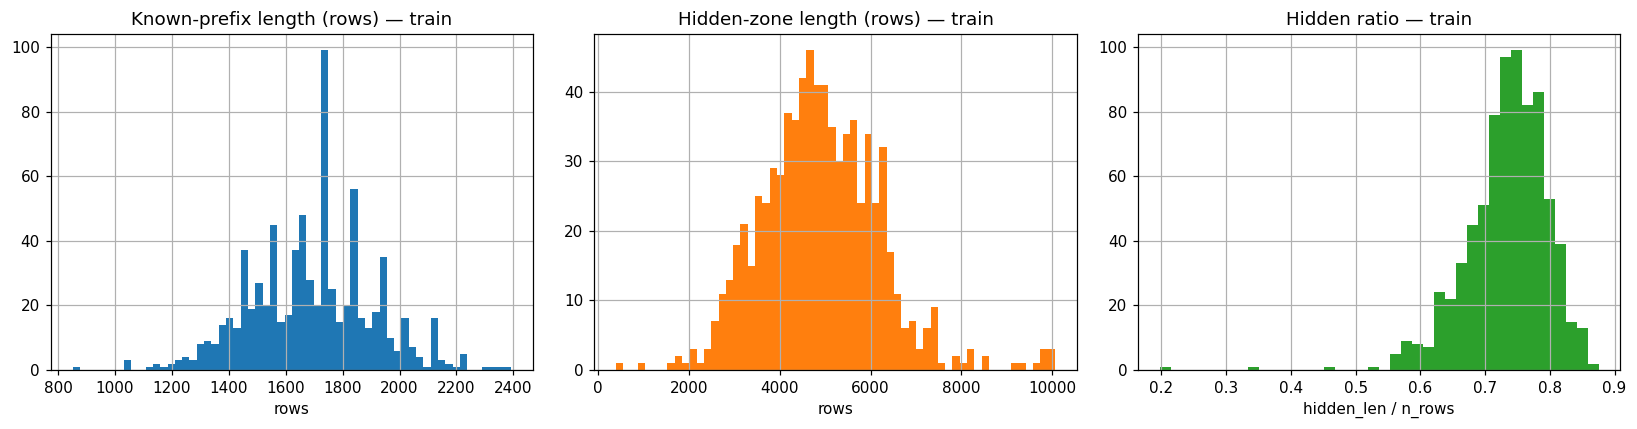

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(train['known_len'], bins=60)
axes[0].set_title('Known-prefix length (rows) — train')
axes[0].set_xlabel('rows')
axes[1].hist(train['hidden_len'], bins=60, color='C1')
axes[1].set_title('Hidden-zone length (rows) — train')
axes[1].set_xlabel('rows')
axes[2].hist(train['hidden_ratio'], bins=40, color='C2')
axes[2].set_title('Hidden ratio — train')
axes[2].set_xlabel('hidden_len / n_rows')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q1_hidden_known_dists.png', bbox_inches='tight')
plt.show()

In [8]:
# Tails
print('Top 5 by hidden_ratio:')
print(train.nlargest(5, 'hidden_ratio')[['well','n_rows','known_len','hidden_len','hidden_ratio']])
print()
print('Bottom 5 by hidden_ratio:')
print(train.nsmallest(5, 'hidden_ratio')[['well','n_rows','known_len','hidden_len','hidden_ratio']])
print()
print('Same view in MD-span (feet):')
print(train[['md_known_span','md_hidden_span']].describe(percentiles=[.05,.5,.95]).round(1))

Top 5 by hidden_ratio:
         well  n_rows  known_len  hidden_len  hidden_ratio
383  86454a6f    9100       1136        7964      0.875165
318  6e9ccd38    9619       1337        8282      0.861004
305  684a6fc1   11449       1631        9818      0.857542
211  46d41ff6    9226       1325        7901      0.856384
104  25050f63    7155       1031        6124      0.855905

Bottom 5 by hidden_ratio:
         well  n_rows  known_len  hidden_len  hidden_ratio
758  fba7683c    2058       1651         407      0.197765
190  404c4384    2612       1701         911      0.348775
614  ce8399b7    3548       1933        1615      0.455186
12   052d64df    4590       2145        2445      0.532680
121  2ab29395    3325       1473        1852      0.556992

Same view in MD-span (feet):
       md_known_span  md_hidden_span
count          773.0           773.0
mean          1691.5          4894.2
std            217.3          1301.2
min            850.0           406.0
5%            1345.0       

## Q2 — TVT trajectory smoothness (train only)

Per-row `dTVT/dMD` (rate of stratigraphic change per unit MD) and
`d²TVT/dMD²` (curvature/jumps) on the **known prefix** of each train well.
Per-well summary is in the cached parquet; here we recompute global
distributions on a representative subsample of rows.

In [9]:
rng = np.random.default_rng(42)
sample = train.sample(min(150, len(train)), random_state=0)['well'].tolist()
all_dtvt, all_d2 = [], []
for w in sample:
    h = pd.read_csv(TRAIN_DIR / f'{w}__horizontal_well.csv',
                    usecols=['MD','TVT','TVT_input'])
    nan_mask = h['TVT_input'].isna().to_numpy()
    first_nan = int(np.argmax(nan_mask)) if nan_mask.any() else len(h)
    if first_nan < 3:
        continue
    md_v = h['MD'].iloc[:first_nan].to_numpy()
    tvt_v = h['TVT'].iloc[:first_nan].to_numpy()
    if not np.all(np.diff(md_v) > 0):
        continue
    dtvt = np.diff(tvt_v) / np.diff(md_v)
    d2 = np.diff(dtvt)
    all_dtvt.append(dtvt)
    all_d2.append(d2)
all_dtvt = np.concatenate(all_dtvt)
all_d2 = np.concatenate(all_d2)
print(f'rows in sample: dtvt={len(all_dtvt):,}  d2={len(all_d2):,}')

rows in sample: dtvt=252,737  d2=252,587


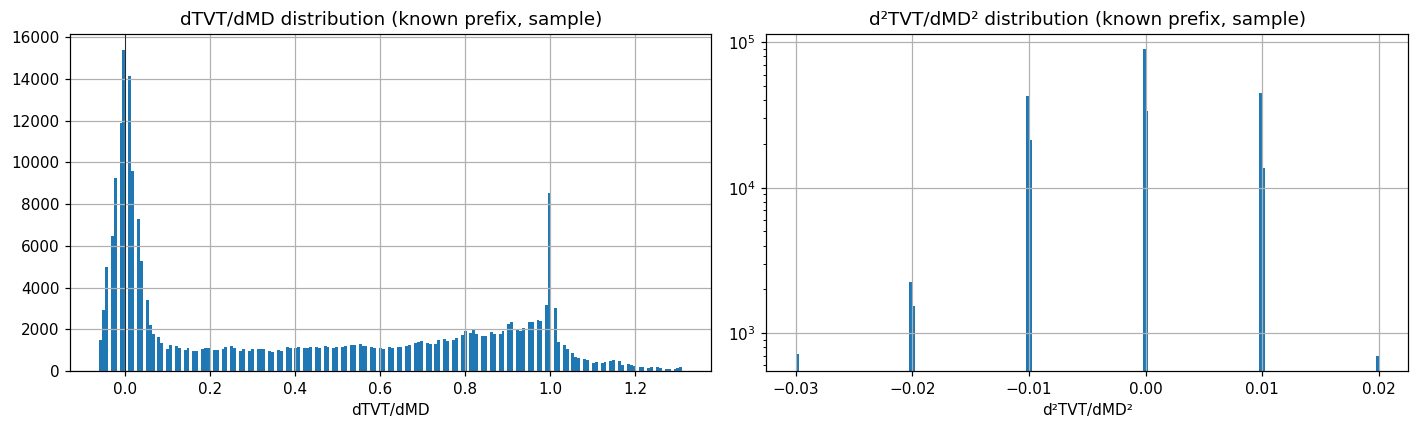

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(all_dtvt, bins=200, range=(np.percentile(all_dtvt,1), np.percentile(all_dtvt,99)))
axes[0].set_title('dTVT/dMD distribution (known prefix, sample)')
axes[0].set_xlabel('dTVT/dMD')
axes[0].axvline(0, color='k', lw=0.5)

axes[1].hist(all_d2, bins=200, range=(np.percentile(all_d2,0.5), np.percentile(all_d2,99.5)))
axes[1].set_title('d²TVT/dMD² distribution (known prefix, sample)')
axes[1].set_xlabel('d²TVT/dMD²')
axes[1].set_yscale('log')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q2_tvt_derivatives.png', bbox_inches='tight')
plt.show()

In [11]:
# Per-well discontinuity flag based on the per-well jumps count from the pipeline.
# n_jumps_3sigma counts |d2| > 8 * MAD(d2). >0 means the well shows step-like behavior.
print('Train n_jumps_3sigma (per well) describe:')
print(train['n_jumps_3sigma'].describe().round(2))
print()
print('Wells with >=1 detected jump:', int((train['n_jumps_3sigma'] >= 1).sum()),
      f"({(train['n_jumps_3sigma'] >= 1).mean()*100:.1f}%)")
print('Wells with >=5 detected jumps:', int((train['n_jumps_3sigma'] >= 5).sum()))
print()
print('Top jumpy wells (potential faults):')
print(train.nlargest(10, 'n_jumps_3sigma')[
    ['well','n_rows','known_len','n_jumps_3sigma','d2tvtdmd2_max_abs','abs_dtvtdmd_max']
])

Train n_jumps_3sigma (per well) describe:
count     773.00
mean      248.72
std       377.89
min         0.00
25%         4.00
50%        10.00
75%       718.00
max      1157.00
Name: n_jumps_3sigma, dtype: float64

Wells with >=1 detected jump: 729 (94.3%)
Wells with >=5 detected jumps: 565

Top jumpy wells (potential faults):
         well  n_rows  known_len  n_jumps_3sigma  d2tvtdmd2_max_abs  abs_dtvtdmd_max
496  a6f967fb    7032       2362            1157               0.67             1.22
365  7ff89f8f    9539       2202            1083               0.08             1.00
12   052d64df    4590       2145            1063               0.40             1.41
347  7850c72e    7712       2215            1060               0.19             1.01
117  28473855    6620       2330            1058               0.10             1.01
767  fdfd57da    7364       2128            1058               1.02             1.90
229  4cd1ac61    6709       2220            1055               1.65        

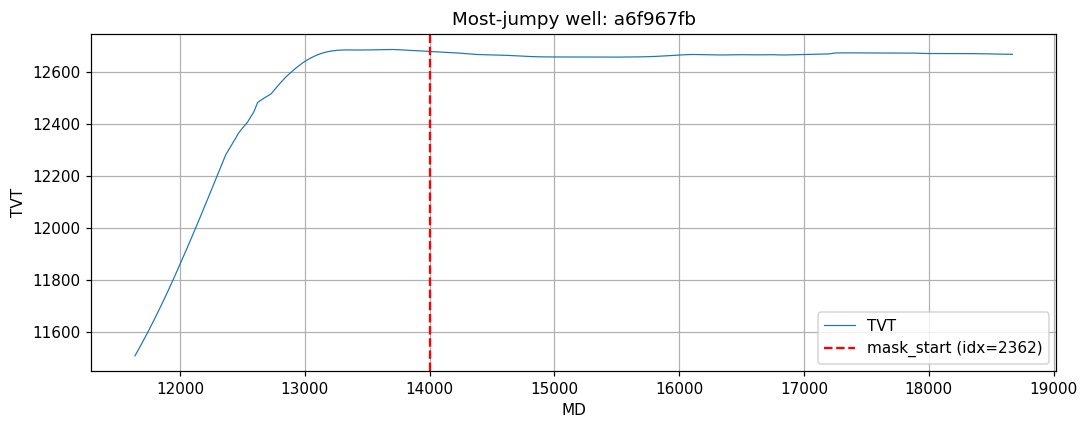

In [12]:
# Visual sanity: plot TVT trace for the most jumpy well
worst = train.nlargest(1, 'n_jumps_3sigma').iloc[0]['well']
h = pd.read_csv(TRAIN_DIR / f'{worst}__horizontal_well.csv', usecols=['MD','TVT','TVT_input'])
nan_mask = h['TVT_input'].isna().to_numpy()
first_nan = int(np.argmax(nan_mask)) if nan_mask.any() else len(h)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h['MD'], h['TVT'], lw=0.8, label='TVT')
ax.axvline(h['MD'].iloc[first_nan], color='r', ls='--', label=f'mask_start (idx={first_nan})')
ax.set_title(f'Most-jumpy well: {worst}')
ax.set_xlabel('MD'); ax.set_ylabel('TVT')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q2_jumpy_{worst}.png', bbox_inches='tight')
plt.show()

## Q3 — GR scale consistency

Per-well GR stats for train wells, test wells, typewells. Then per-well
horizontal-vs-typewell offset/ratio to see whether they are calibrated.

In [13]:
def desc(d, label):
    rows = []
    for col, name in [('mean','mean'), ('std','std'), ('p10','p10'), ('p50','p50'), ('p90','p90')]:
        rows.append({'stat': name, 'value_mean': d[col].mean(), 'value_std': d[col].std()})
    print(label, '— per-well GR stats summary across wells:')
    print(pd.DataFrame(rows).round(2).to_string(index=False))
    print()

desc(train.assign(mean=train['gr_mean'], std=train['gr_std'],
                  p10=train['gr_p10'], p50=train['gr_p50'], p90=train['gr_p90']),
     'TRAIN horizontal')
desc(test.assign(mean=test['gr_mean'], std=test['gr_std'],
                 p10=test['gr_p10'], p50=test['gr_p50'], p90=test['gr_p90']),
     'TEST horizontal (known + hidden)')
desc(train.assign(mean=train['tw_gr_mean'], std=train['tw_gr_std'],
                  p10=train['tw_gr_p10'], p50=train['tw_gr_p50'], p90=train['tw_gr_p90']),
     'TRAIN typewells')
desc(test.assign(mean=test['tw_gr_mean'], std=test['tw_gr_std'],
                 p10=test['tw_gr_p10'], p50=test['tw_gr_p50'], p90=test['tw_gr_p90']),
     'TEST typewells')

TRAIN horizontal — per-well GR stats summary across wells:
stat  value_mean  value_std
mean       88.10      15.38
 std       17.86       3.99
 p10       67.43      12.55
 p50       87.32      16.54
 p90      110.20      17.98

TEST horizontal (known + hidden) — per-well GR stats summary across wells:
stat  value_mean  value_std
mean       78.78      21.99
 std       23.03       8.94
 p10       56.67      25.24
 p50       74.26      29.70
 p90      113.46       4.54

TRAIN typewells — per-well GR stats summary across wells:
stat  value_mean  value_std
mean       88.72      14.74
 std       29.89       6.22
 p10       44.62       9.28
 p50       91.35      15.81
 p90      123.64      21.49

TEST typewells — per-well GR stats summary across wells:
stat  value_mean  value_std
mean       90.46       6.47
 std       25.80       2.11
 p10       48.93       9.16
 p50       96.08       8.01
 p90      117.49       3.89



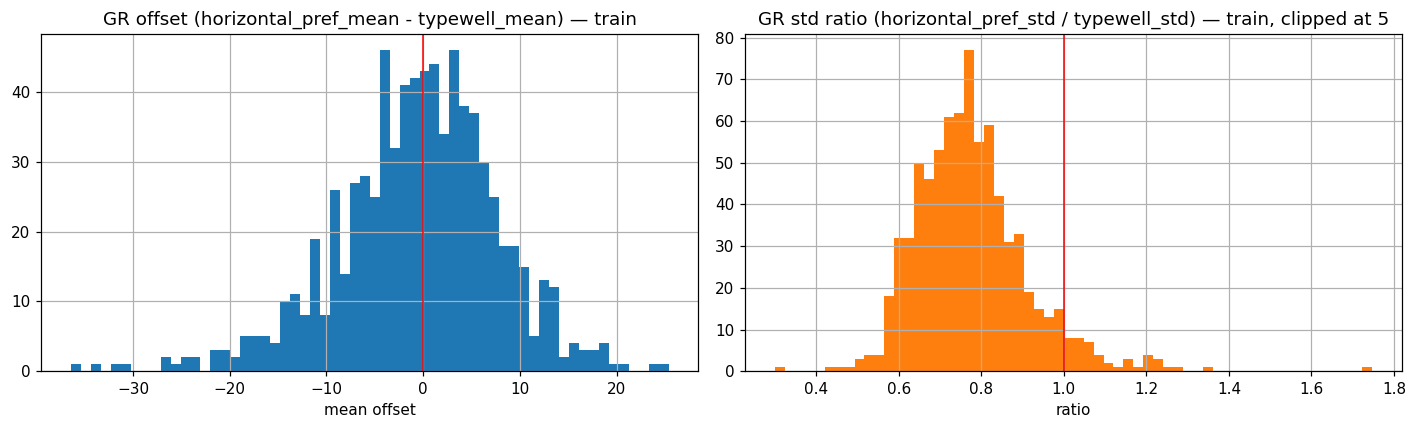

Train offset describe:
count    773.00
mean      -0.60
std        8.36
min      -36.42
5%       -14.73
50%        0.09
95%       12.43
max       25.38
Name: gr_scale_offset, dtype: float64

Train std-ratio describe:
count    773.00
mean       0.78
std        0.14
min        0.30
5%         0.59
50%        0.76
95%        1.02
max        1.75
Name: gr_scale_ratio, dtype: float64


In [14]:
# Horizontal vs own typewell calibration (offset & ratio of std)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train['gr_scale_offset'], bins=60)
axes[0].axvline(0, color='r', lw=1)
axes[0].set_title('GR offset (horizontal_pref_mean - typewell_mean) — train')
axes[0].set_xlabel('mean offset')

ratio = train['gr_scale_ratio'].clip(0, 5)
axes[1].hist(ratio, bins=60, color='C1')
axes[1].axvline(1, color='r', lw=1)
axes[1].set_title('GR std ratio (horizontal_pref_std / typewell_std) — train, clipped at 5')
axes[1].set_xlabel('ratio')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q3_gr_offset_ratio.png', bbox_inches='tight')
plt.show()

print('Train offset describe:')
print(train['gr_scale_offset'].describe(percentiles=[.05,.5,.95]).round(2))
print()
print('Train std-ratio describe:')
print(train['gr_scale_ratio'].describe(percentiles=[.05,.5,.95]).round(2))

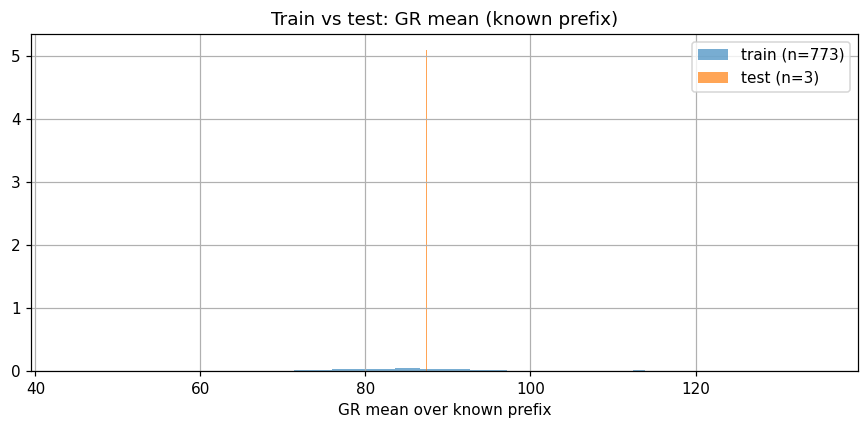

Test wells GR detail:
         well  gr_pref_mean  gr_pref_std  gr_pref_p10  gr_pref_p50  gr_pref_p90  tw_gr_mean  tw_gr_std  gr_scale_offset  gr_scale_ratio  gr_ks_proxy
773  000d7d20         87.42        22.01        57.94        89.25       112.83       83.26      26.24             4.16            0.84         0.61
774  00bbac68         88.93        21.61        59.71        89.93       116.00       92.34      27.65            -3.42            0.78         0.51
775  00e12e8b         85.00        41.07        28.23       102.07       130.49       95.77      23.50           -10.77            1.75         1.17


In [15]:
# Train vs test GR distributions (use horizontal-known prefix mean for fair compare)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train['gr_pref_mean'], bins=60, alpha=0.6, label=f'train (n={len(train)})', density=True)
ax.hist(test['gr_pref_mean'], bins=60, alpha=0.7, label=f'test (n={len(test)})', density=True)
ax.set_xlabel('GR mean over known prefix')
ax.set_title('Train vs test: GR mean (known prefix)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q3_train_vs_test_gr.png', bbox_inches='tight')
plt.show()

print('Test wells GR detail:')
print(test[['well','gr_pref_mean','gr_pref_std','gr_pref_p10','gr_pref_p50','gr_pref_p90',
            'tw_gr_mean','tw_gr_std','gr_scale_offset','gr_scale_ratio','gr_ks_proxy']].round(2))

## Q4 — Typewell coverage

For each well, does the horizontal's `TVT_input` range fit inside the typewell's
TVT range?

In [16]:
print('Train wells whose horizontal TVT_input is fully inside typewell TVT range:')
print(' ', int(train['cov_inside'].sum()), '/', len(train),
      f"({train['cov_inside'].mean()*100:.1f}%)")
print()
print('Train cov_low_margin (TVT_input_min - typewell_min) describe (>=0 means inside):')
print(train['cov_low_margin'].describe(percentiles=[.05,.5,.95]).round(2))
print()
print('Train cov_high_margin describe:')
print(train['cov_high_margin'].describe(percentiles=[.05,.5,.95]).round(2))

Train wells whose horizontal TVT_input is fully inside typewell TVT range:
  760 / 773 (98.3%)

Train cov_low_margin (TVT_input_min - typewell_min) describe (>=0 means inside):
count    773.00
mean       5.82
std       56.26
min     -644.77
5%        12.06
50%       12.33
95%       12.53
max       12.55
Name: cov_low_margin, dtype: float64

Train cov_high_margin describe:
count    773.00
mean     155.68
std       51.03
min       -1.29
5%        84.18
50%      151.43
95%      247.79
max      341.56
Name: cov_high_margin, dtype: float64


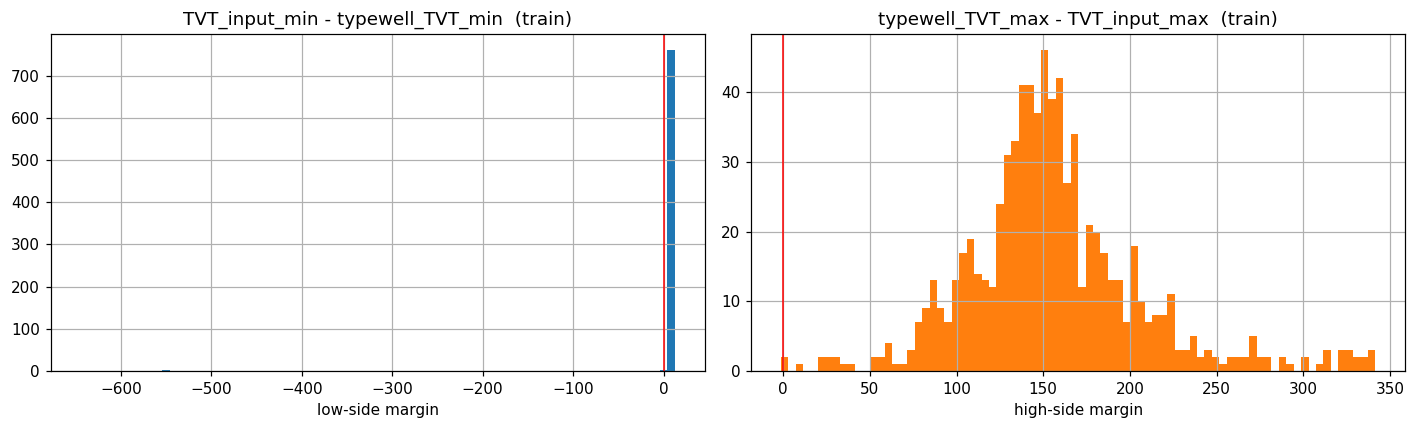

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train['cov_low_margin'], bins=80)
axes[0].axvline(0, color='r', lw=1)
axes[0].set_title('TVT_input_min - typewell_TVT_min  (train)')
axes[0].set_xlabel('low-side margin')
axes[1].hist(train['cov_high_margin'], bins=80, color='C1')
axes[1].axvline(0, color='r', lw=1)
axes[1].set_title('typewell_TVT_max - TVT_input_max  (train)')
axes[1].set_xlabel('high-side margin')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q4_typewell_coverage.png', bbox_inches='tight')
plt.show()

In [18]:
# Wells where the lateral exits the typewell
exits = train[~train['cov_inside']]
print(f'Wells where lateral exits typewell: {len(exits)}')
print(exits[['well','tvt_input_min','tvt_input_max','tw_tvt_min','tw_tvt_max',
             'cov_low_margin','cov_high_margin']].head(10).round(2))
print()
print('Test wells coverage:')
print(test[['well','tvt_input_min','tvt_input_max','tw_tvt_min','tw_tvt_max',
            'cov_inside','cov_low_margin','cov_high_margin']].round(2))

Wells where lateral exits typewell: 13
         well  tvt_input_min  tvt_input_max  tw_tvt_min  tw_tvt_max  cov_low_margin  cov_high_margin
7    02e7fe5a       11356.13       12178.98    11782.62    12285.10         -426.49           106.12
27   0bbf5e67       10180.13       10972.06    10167.95    10971.95           12.18            -0.11
37   10b89021       11311.08       12161.18    11782.62    12285.10         -471.54           123.92
130  2cee0cba       10463.67       11246.74    10451.45    11245.45           12.22            -1.29
152  3417285d       11137.85       12164.85    11782.62    12285.10         -644.77           120.25
182  3c3dbcbc       11051.24       11860.06    11168.90    12051.84         -117.66           191.78
312  6ae68655       11387.98       12130.23    11782.62    12285.10         -394.64           154.87
352  7993a768       11439.17       12157.98    11782.62    12285.10         -343.45           127.12
555  bc4381e2       11207.21       12132.27    11782

## Q5 — Per-well difficulty proxies & clustering

Using train-only difficulty features (we do NOT use TVT for test, so the
clustering here is descriptive of train wells only).

silhouette by k: {2: 0.149, 3: 0.158, 4: 0.165, 5: 0.187, 6: 0.201}
chosen k = 6


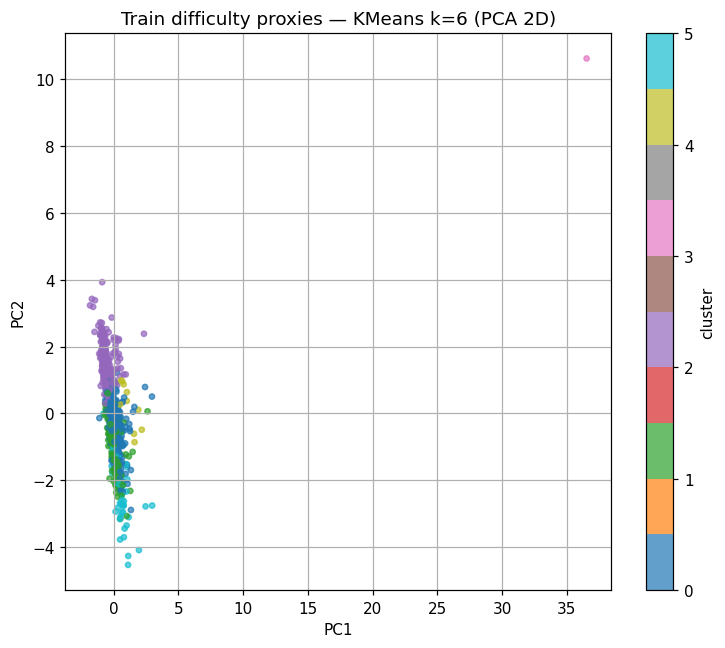


Cluster medians (rows = cluster id):
         hidden_len  known_len  abs_dtvtdmd_mean  abs_dtvtdmd_max  d2tvtdmd2_std  n_jumps_3sigma  gr_scale_offset  gr_scale_ratio  gr_ks_proxy  cov_low_margin  cov_high_margin
cluster                                                                                                                                                                        
0            4864.0     1749.0              0.46             1.35           0.02             6.0            -1.61            0.78         0.61           12.32           145.20
1            4753.0     1777.0              0.45             1.06           0.01           850.0            -3.42            0.76         0.65           12.33           150.43
2            4897.5     1495.5              0.36             1.13           0.02             7.0             5.54            0.72         0.79           12.35           151.25
3            5069.0     1842.0              0.54           151.38           5.02  

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

feat_cols = ['hidden_len','known_len','abs_dtvtdmd_mean','abs_dtvtdmd_max',
             'd2tvtdmd2_std','n_jumps_3sigma','gr_scale_offset','gr_scale_ratio',
             'gr_ks_proxy','cov_low_margin','cov_high_margin']
X = train[feat_cols].fillna(train[feat_cols].median())
Xs = StandardScaler().fit_transform(X)

# pick k by silhouette quickly
from sklearn.metrics import silhouette_score
scores = {}
for k in (2,3,4,5,6):
    lbl = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    scores[k] = silhouette_score(Xs, lbl)
print('silhouette by k:', {k: round(v,3) for k,v in scores.items()})
best_k = max(scores, key=scores.get)
print('chosen k =', best_k)

km = KMeans(n_clusters=best_k, n_init=20, random_state=0).fit(Xs)
train['cluster'] = km.labels_
pca = PCA(n_components=2, random_state=0).fit(Xs)
P = pca.transform(Xs)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(P[:,0], P[:,1], c=km.labels_, cmap='tab10', s=12, alpha=0.7)
ax.set_title(f'Train difficulty proxies — KMeans k={best_k} (PCA 2D)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='cluster')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q5_difficulty_clusters.png', bbox_inches='tight')
plt.show()

cluster_profile = train.groupby('cluster')[feat_cols].median().round(2)
print()
print('Cluster medians (rows = cluster id):')
print(cluster_profile)
print()
print('Cluster sizes:')
print(train['cluster'].value_counts().sort_index())

## Q6 — Spatial layout

Centroids (X, Y), pad/field clustering, and nearest-neighbor distances.

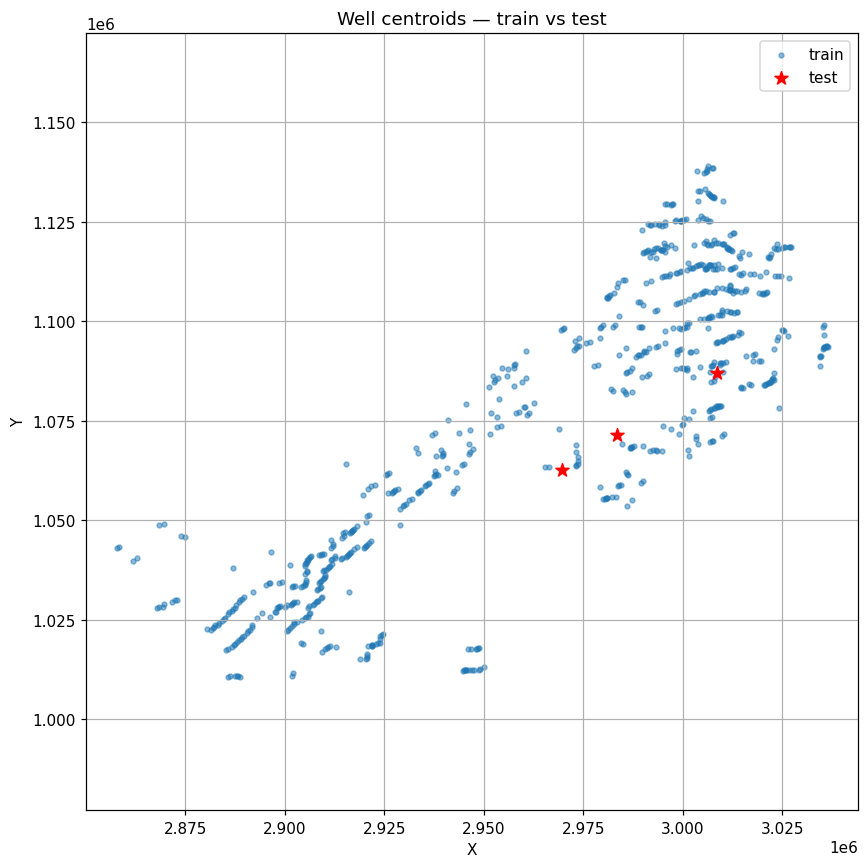

X range train: 2857752.3 → 3036410.5  span: 178658.2
Y range train: 1010589.1 → 1138904.2  span: 128315.2
Test centroids:
         well     x_mean     y_mean
773  000d7d20  2983513.9  1071417.7
774  00bbac68  3008500.4  1086928.4
775  00e12e8b  2969568.6  1062552.7


In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(train['x_mean'], train['y_mean'], s=10, alpha=0.5, label='train')
ax.scatter(test['x_mean'], test['y_mean'], s=80, marker='*', color='red', label='test')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Well centroids — train vs test')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q6_centroids.png', bbox_inches='tight')
plt.show()

print('X range train:', round(train.x_mean.min(),1), '→', round(train.x_mean.max(),1),
      ' span:', round(train.x_mean.max() - train.x_mean.min(),1))
print('Y range train:', round(train.y_mean.min(),1), '→', round(train.y_mean.max(),1),
      ' span:', round(train.y_mean.max() - train.y_mean.min(),1))
print('Test centroids:')
print(test[['well','x_mean','y_mean']].round(1))

DBSCAN eps=893.3: clusters=106, noise=274


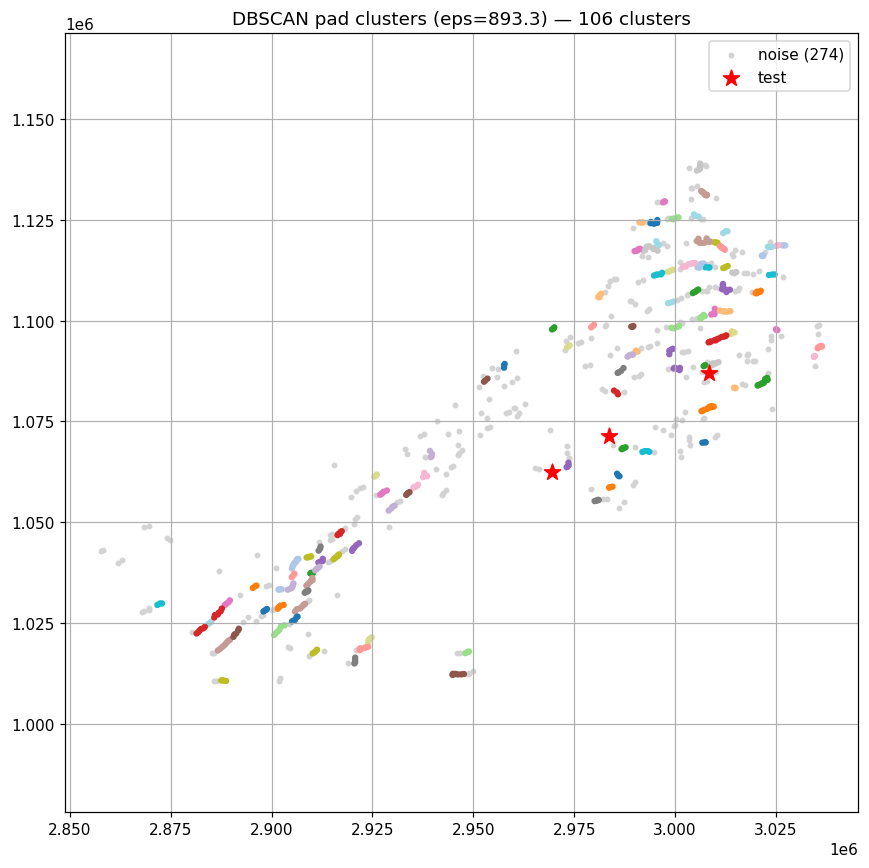

In [21]:
from sklearn.cluster import DBSCAN
# Pick eps by visual inspection: use 2% of x-span as a starting heuristic
xy = train[['x_mean','y_mean']].to_numpy()
span = max(train.x_mean.max() - train.x_mean.min(),
           train.y_mean.max() - train.y_mean.min())
eps = span * 0.005   # 0.5% of bbox span — tight pad-scale
db = DBSCAN(eps=eps, min_samples=3).fit(xy)
labels = db.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())
print(f'DBSCAN eps={eps:.1f}: clusters={n_clusters}, noise={n_noise}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(xy[labels==-1,0], xy[labels==-1,1], s=8, c='lightgray', label=f'noise ({n_noise})')
mask = labels != -1
ax.scatter(xy[mask,0], xy[mask,1], s=10, c=labels[mask], cmap='tab20')
ax.scatter(test['x_mean'], test['y_mean'], s=120, marker='*', color='red', label='test')
ax.set_aspect('equal', adjustable='datalim')
ax.set_title(f'DBSCAN pad clusters (eps={eps:.1f}) — {n_clusters} clusters')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q6_dbscan.png', bbox_inches='tight')
plt.show()

In [22]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=6).fit(train[['x_mean','y_mean']].to_numpy())
test_xy = test[['x_mean','y_mean']].to_numpy()
dists, idx = nn.kneighbors(test_xy)
# col 0 is the nearest train neighbor — same well by name presumably
for i, w in enumerate(test['well'].tolist()):
    nearest_idx = idx[i, 0]
    nn_well = train.iloc[nearest_idx]['well']
    same_name = (nn_well == w)
    print(f'test {w}: nearest train = {nn_well} (dist={dists[i,0]:.2f}, same name: {same_name})')
    print(f'  next 5 distances: {[round(d,1) for d in dists[i,1:6]]}')

test 000d7d20: nearest train = 000d7d20 (dist=0.00, same name: True)
  next 5 distances: [np.float64(466.5), np.float64(2430.1), np.float64(4577.4), np.float64(4650.5), np.float64(4723.6)]
test 00bbac68: nearest train = 00bbac68 (dist=0.00, same name: True)
  next 5 distances: [np.float64(1010.0), np.float64(1749.4), np.float64(1771.7), np.float64(2041.5), np.float64(2224.4)]
test 00e12e8b: nearest train = 00e12e8b (dist=0.00, same name: True)
  next 5 distances: [np.float64(370.4), np.float64(3249.7), np.float64(3726.2), np.float64(3909.5), np.float64(4300.8)]


In [23]:
# Are typewell files ever shared (i.e., identical content) across multiple wells?
import hashlib
hashes = {}
for split, d in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    for w in list_wells(d):
        with open(d / f'{w}__typewell.csv', 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes.setdefault(h, []).append(f'{split}/{w}')
shared = {h: ws for h, ws in hashes.items() if len(ws) > 1}
print(f'Distinct typewell content hashes: {len(hashes)}')
print(f'Hashes shared by >1 well: {len(shared)}')
if shared:
    for h, ws in list(shared.items())[:8]:
        print(f'  hash {h[:8]}: {ws}')

Distinct typewell content hashes: 755
Hashes shared by >1 well: 13
  hash a23359a1: ['train/02e7fe5a', 'train/10b89021', 'train/3417285d', 'train/6ae68655', 'train/7993a768', 'train/bc4381e2', 'train/ecdab904', 'train/f021b650', 'train/f49fdea3', 'train/f88ddb26']
  hash 2c2b43cb: ['train/071d7b45', 'train/4463446c']
  hash b759a49e: ['train/25939962', 'train/8050c789']
  hash a190a271: ['train/2f8e53c3', 'train/91db7070']
  hash a37c8cde: ['train/75cd5f11', 'train/be83e781']
  hash 9313fb06: ['train/7b38844c', 'train/ed6e6e54']
  hash a1e478c8: ['train/89f1085d', 'train/aed44918']
  hash 5e32e00b: ['train/8b95d6d1', 'train/a2e8e7f6']


## Q7 — Train/test distribution alignment

In [24]:
def quick_compare(col, label=None):
    label = label or col
    a = train[col].dropna()
    b = test[col].dropna()
    print(f'{label:25s}  train: mean={a.mean():9.2f} std={a.std():9.2f} '
          f'min={a.min():9.2f} max={a.max():9.2f}    test: '
          f'mean={b.mean():9.2f} std={b.std():9.2f} min={b.min():9.2f} max={b.max():9.2f}')

for c, lbl in [
    ('known_len',     'known_len (rows)'),
    ('hidden_len',    'hidden_len (rows)'),
    ('hidden_ratio',  'hidden_ratio'),
    ('md_known_span', 'md_known_span'),
    ('md_hidden_span','md_hidden_span'),
    ('gr_pref_mean',  'GR mean (pref)'),
    ('gr_pref_std',   'GR std (pref)'),
    ('z_min',         'Z min'),
    ('z_max',         'Z max'),
    ('x_mean',        'X mean'),
    ('y_mean',        'Y mean'),
]:
    quick_compare(c, lbl)

known_len (rows)           train: mean=  1692.45 std=   217.34 min=   851.00 max=  2392.00    test: mean=  1690.00 std=   344.22 min=  1442.00 max=  2083.00
hidden_len (rows)          train: mean=  4895.20 std=  1301.18 min=   407.00 max= 10052.00    test: mean=  4717.00 std=  1147.05 min=  3836.00 max=  6014.00
hidden_ratio               train: mean=     0.73 std=     0.06 min=     0.20 max=     0.88    test: mean=     0.73 std=     0.06 min=     0.67 max=     0.80
md_known_span              train: mean=  1691.45 std=   217.34 min=   850.00 max=  2391.00    test: mean=  1689.00 std=   344.22 min=  1441.00 max=  2082.00
md_hidden_span             train: mean=  4894.20 std=  1301.18 min=   406.00 max= 10051.00    test: mean=  4716.00 std=  1147.05 min=  3835.00 max=  6013.00
GR mean (pref)             train: mean=    88.12 std=    13.73 min=    44.08 max=   135.14    test: mean=    87.11 std=     1.98 min=    85.00 max=    88.93
GR std (pref)              train: mean=    22.99 std=     

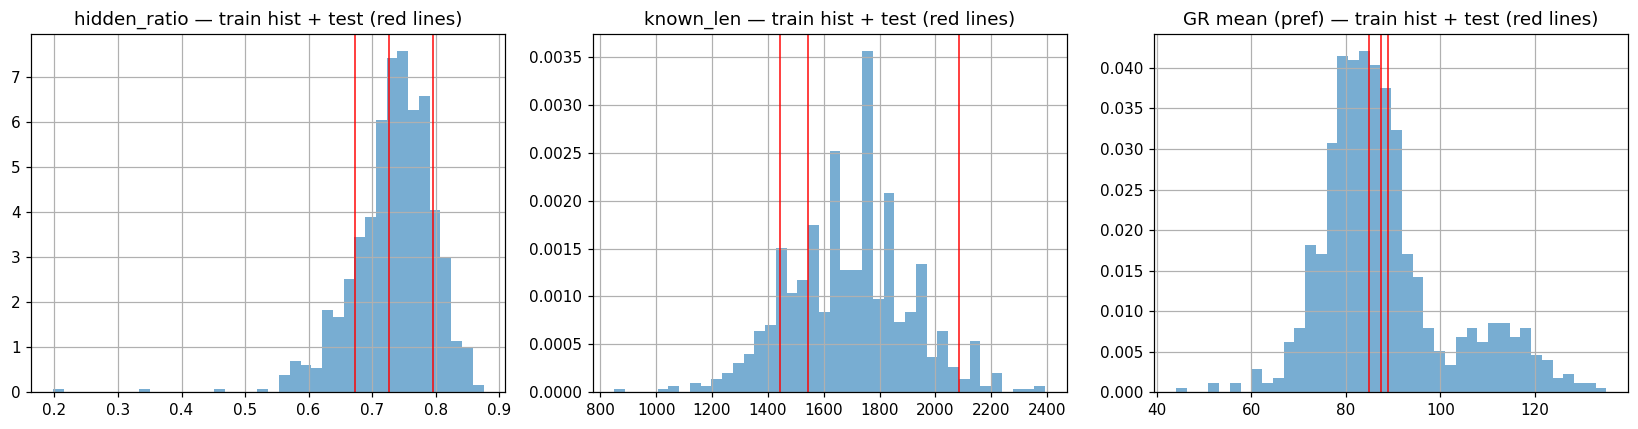

In [25]:
# Visual side-by-side for the most operationally important: hidden_ratio + known_len + GR mean
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ttl in zip(axes,
                         ['hidden_ratio', 'known_len', 'gr_pref_mean'],
                         ['hidden_ratio', 'known_len', 'GR mean (pref)']):
    bins = 40
    ax.hist(train[col], bins=bins, alpha=0.6, density=True, label=f'train (n={len(train)})')
    for v in test[col]:
        ax.axvline(v, color='red', lw=1.2, alpha=0.8)
    ax.set_title(ttl + ' — train hist + test (red lines)')
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/q7_train_vs_test.png', bbox_inches='tight')
plt.show()

## Sanity / leakage audit

In [26]:
audit = leakage_audit()
for w, info in audit.items():
    print(w, info)

000d7d20 {'leak_cols_present': [], 'first_nan_idx': 1442, 'n_total': 5278, 'n_nan': 3836, 'before_clean': True, 'after_all_nan': True}
00bbac68 {'leak_cols_present': [], 'first_nan_idx': 1545, 'n_total': 7559, 'n_nan': 6014, 'before_clean': True, 'after_all_nan': True}
00e12e8b {'leak_cols_present': [], 'first_nan_idx': 2083, 'n_total': 6384, 'n_nan': 4301, 'before_clean': True, 'after_all_nan': True}


In [27]:
# Confirm no test PNGs
test_pngs = [w for w in list_wells(TEST_DIR) if (TEST_DIR / f'{w}.png').exists()]
print(f'Test PNGs present: {len(test_pngs)} (expected 0)')

# Spot-check 2 train PNGs
from PIL import Image
for w in list_wells(TRAIN_DIR)[:2]:
    p = TRAIN_DIR / f'{w}.png'
    if p.exists():
        with Image.open(p) as im:
            print(f'{w}.png  size={im.size}  mode={im.mode}')

Test PNGs present: 0 (expected 0)
000d7d20.png  size=(4984, 2805)  mode=RGBA
00bbac68.png  size=(5010, 2805)  mode=RGBA


## Notes for the next session

Key takeaways are summarised in `eda_findings.md`. Numbers above feed directly
into the journal entry for this session.